In [ ]:
# 1. 匯入必要套件
import os
import pandas as pd
import numpy as np
from datetime import datetime
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from pmdarima import auto_arima
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# 匯入fetch_stock_with_indicators.py的爬蟲程式
from stock_scraper_with_indicators import fetch_and_add_indicators

# 設定繪圖風格
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 顯示中文
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 2. 資料管線自動化 (自動檢查並下載最新股價)

stock_mapping = {"台積電": "2330", "鴻海": "2317", "聯發科": "2454", "長榮": "2603", "蘋果": "AAPL"}
user_input = input("請輸入你想分析的股票名稱或代號: ").strip()

# 解析代號
if user_input in stock_mapping:
    clean_ticker = stock_mapping[user_input]
    yf_ticker = f"{clean_ticker}.TW" if clean_ticker.isdigit() else clean_ticker
elif user_input.isdigit() and len(user_input) == 4:
    clean_ticker = user_input
    yf_ticker = f"{user_input}.TW"
else:
    clean_ticker = user_input.upper().replace('.TW', '') 
    yf_ticker = user_input.upper()
    clean_ticker = user_input.upper().replace('.TW', '') 
    yf_ticker = user_input.upper()

# 設定與爬蟲相同的目標資料夾
save_dir = r"D:\桌布\github\Stock csv files"

# 確保資料夾存在
os.makedirs(save_dir, exist_ok=True)
file_name = os.path.join(save_dir, f"{clean_ticker}.csv")   # 將檔名與資料夾路徑結合，變成完整的檔案路徑

# 檢查檔案狀態並決定是否抓取
need_download = True
if os.path.exists(file_name):
    file_date = datetime.fromtimestamp(os.path.getmtime(file_name)).date()
    if file_date == datetime.today().date():
        print(f"✅ 發現今日已更新的檔案 {file_name}，直接讀取！")
        need_download = False
    else:
        print(f"⚠️ 檔案 {file_name} 已經舊了 (最後更新: {file_date})，準備下載最新資料...")

if need_download:
    print(f"⏳ 正在呼叫爬蟲程式，抓取 {yf_ticker} 的最新資料...")
    df_fetched = fetch_and_add_indicators(yf_ticker)
    if df_fetched is not None:
        print("✅ 最新資料抓取與儲存完成！")
if not os.path.exists(file_name):
    raise FileNotFoundError(f"🛑 找不到檔案 {file_name}！請確認你輸入的股票代號是否正確，程式已停止執行。")

# 如果檔案存在，則安全地讀取並清理資料
df = pd.read_csv(file_name, index_col='Date', parse_dates=True).sort_index().dropna()
print(f"📊 成功載入 {file_name}，共 {len(df)} 筆有效交易日資料。")

# 決定要預測未來的幾天 (這裡設定為 5 天)
forecast_horizon = 5

⏳ 正在呼叫爬蟲程式，抓取 0050.TW 的最新資料...
開始抓取 0050.TW 股價資料...


[*********************100%***********************]  1 of 1 completed

計算技術指標中 (MA, RSI, MACD, Bollinger Bands)...
處理完成！檔案已儲存為: D:\桌布\github\Stock csv files\0050.csv
✅ 最新資料抓取與儲存完成！
📊 成功載入 D:\桌布\github\Stock csv files\0050.csv，共 466 筆有效交易日資料。


# 資料預處理與空值檢驗 (Data Prep)

In [ ]:
# 2. 讀取資料與空值處理
df = pd.read_csv(file_name, index_col='Date', parse_dates=True)

# 下面接著清理資料
df = df.sort_index()
df = df.dropna()
print(f"📊 成功載入 {file_name}，共 {len(df)} 筆有效交易日資料。")

print("=== 第一步：檢查原始空值狀況 ===")
print(df.isnull().sum())

# 執行前向填充 (ffill) 來處理未開盤或遺失的資料
df = df.ffill()

print("\n=== 第二步：前向填充後，再次檢查空值 ===")
print(df.isnull().sum())

# 我們只取 'Close' (收盤價) 進行單變量時間序列預測
ts_data = df[['Close']].copy()
print(f"\n資料範圍: {ts_data.index.min().date()} 到 {ts_data.index.max().date()}")

📊 成功載入 D:\桌布\github\Stock csv files\0050.csv，共 466 筆有效交易日資料。
=== 第一步：檢查原始空值狀況 ===
Open           0
High           0
Low            0
Close          0
Volume         0
MA_5           0
MA_10          0
MA_20          0
RSI_14         0
MACD           0
Signal_Line    0
BB_Middle      0
BB_Upper       0
BB_Lower       0
dtype: int64

=== 第二步：前向填充後，再次檢查空值 ===
Open           0
High           0
Low            0
Close          0
Volume         0
MA_5           0
MA_10          0
MA_20          0
RSI_14         0
MACD           0
Signal_Line    0
BB_Middle      0
BB_Upper       0
BB_Lower       0
dtype: int64

資料範圍: 2024-04-02 到 2026-03-06


# 建立評估函數與資料拆分 (Train/Test Split)

In [ ]:
# 3. 模型評估函數與資料切分
def evaluate_forecast(actual, predicted, model_name):
    """計算 MAE, RMSE, MAPE"""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"[{model_name}] 評估結果:")
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%\n")

# 定義預測天數
forecast_horizon = 5 

# Train / Test Split
# 將最後 5 天作為 Test set (模擬真實世界要預測的未來 5 天)
train = ts_data.iloc[:-forecast_horizon]
test = ts_data.iloc[-forecast_horizon:]

print(f"訓練集資料筆數: {len(train)}")
print(f"測試集(欲預測的未來5天)日期: \n{test.index.date}")

# 繪圖輔助函數 (僅顯示最後 60 天交易日 + 預測期)
def plot_future_forecast(history_df, forecast_values, title, zoom_days=60):
    plt.figure(figsize=(10, 5))
    
    # 1. 擷取最近 60 天的歷史資料
    recent_history = history_df.iloc[-zoom_days:]
    plt.plot(recent_history.index, recent_history['Close'], label=f'History (最近 {zoom_days} 天)', color='blue')
    
    # 2. 產生未來的交易日期 (排除六日)
    last_date = history_df.index[-1]
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=len(forecast_values))
    clean_values = np.array(forecast_values).flatten()
    aligned_forecast = pd.Series(clean_values, index=future_dates)
    
    # 3. 解決斷線問題
    last_history_value = history_df['Close'].iloc[-1]
    plot_dates = [last_date] + list(aligned_forecast.index)
    plot_values = [last_history_value] + list(aligned_forecast.values)
    
    # 4. 畫出未來的預測線
    plt.plot(plot_dates, plot_values, label='Future Forecast (未來預測)', color='red', linestyle='--')
    
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

訓練集資料筆數: 461
測試集(欲預測的未來5天)日期: 
[datetime.date(2026, 3, 2) datetime.date(2026, 3, 3)
 datetime.date(2026, 3, 4) datetime.date(2026, 3, 5)
 datetime.date(2026, 3, 6)]


# 探索性資料分析 (EDA: Returns & ACF/PACF)

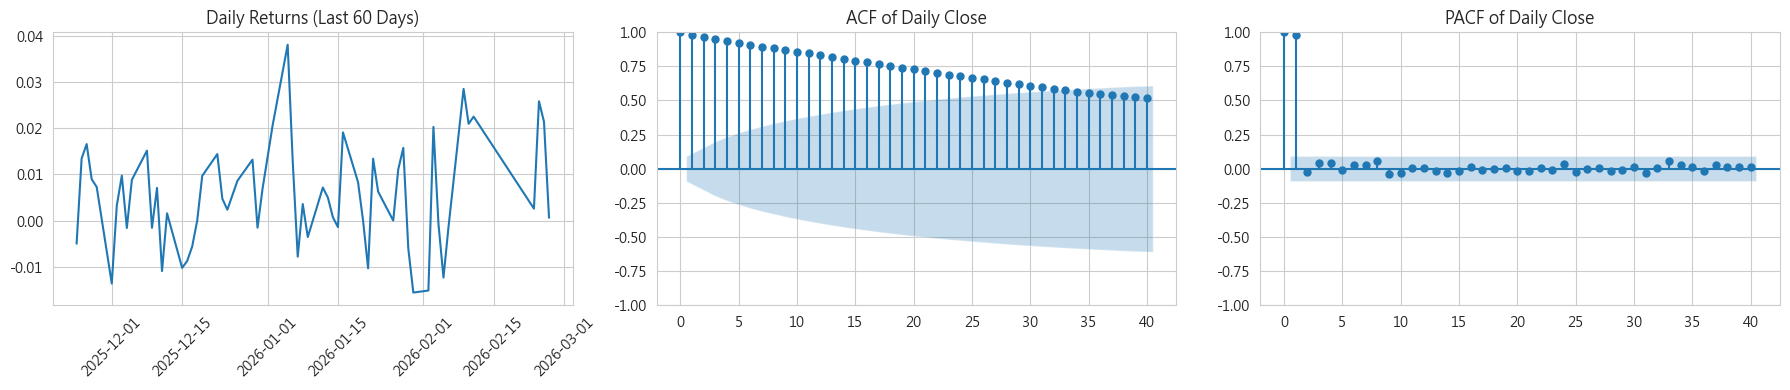

In [7]:
# 4. EDA 觀察每日報酬率與自相關性
# 計算日報酬率
train_returns = train['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(train_returns.index[-60:], train_returns.iloc[-60:])
axes[0].set_title("Daily Returns (Last 60 Days)")
axes[0].tick_params(axis='x', rotation=45)

# 觀察 ACF 與 PACF (日線資料通常看 40 個 lags 內即可)
plot_acf(train['Close'], lags=40, ax=axes[1], title="ACF of Daily Close")
plot_pacf(train['Close'], lags=40, ax=axes[2], title="PACF of Daily Close")
plt.tight_layout()
plt.show()

# 附註：日線股價的 ACF 通常呈現高度持續性 (Non-stationary)，這暗示模型若只看差分前的價格，很容易產生 Lag-1 的平移預測。

# 基礎統計模型 (Naive & Moving Average)

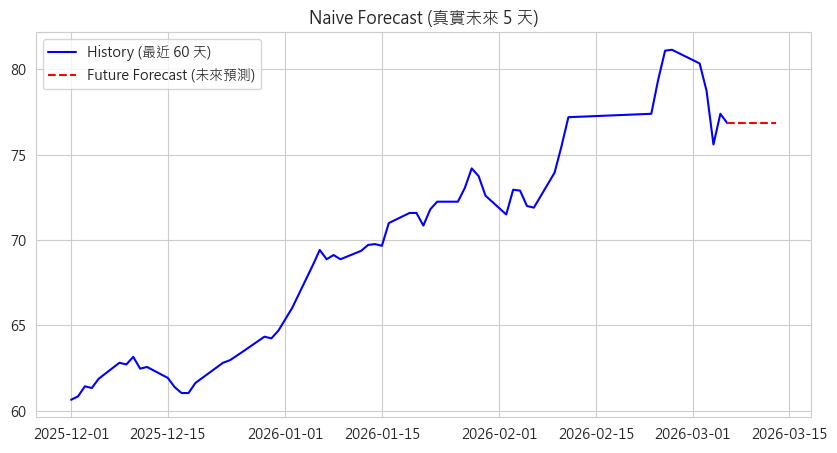

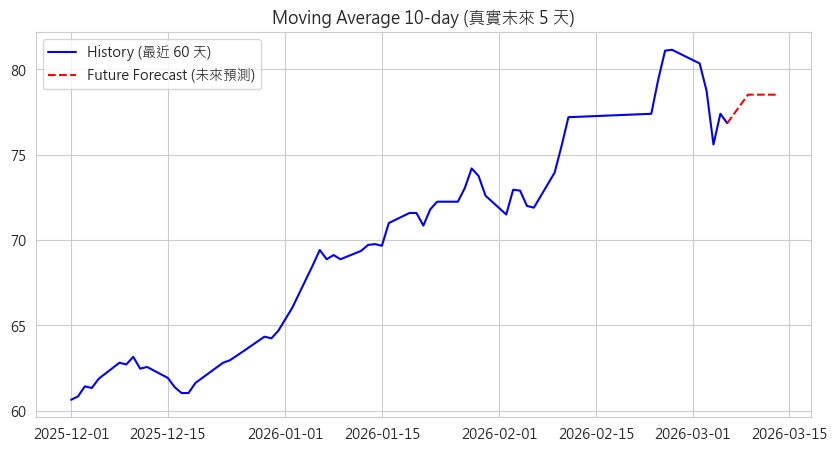

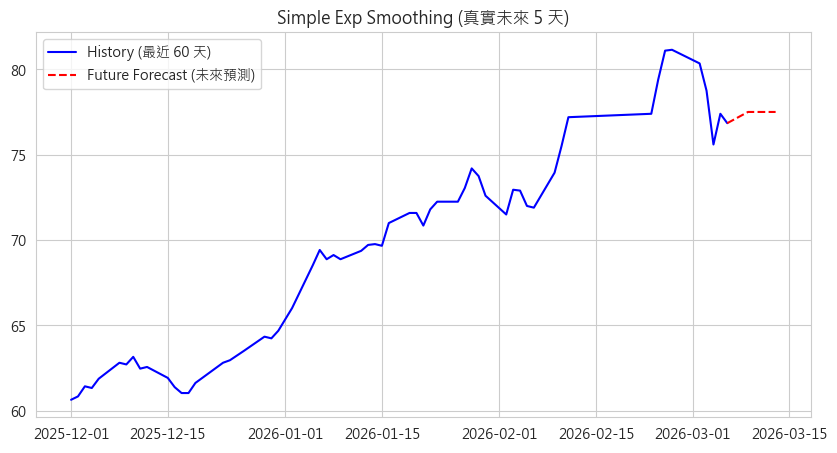

In [8]:
# 5. 基於全部最新資料 (df) 進行真正的未來 5 天預測
# 5.1 Naive Forecast (單純以「今天」的收盤價，預測未來 5 天)
last_close = df['Close'].iloc[-1]
naive_forecast = np.repeat(last_close, forecast_horizon)

# 畫出未來的圖 (不再進行誤差評估，因為未來還沒發生)
plot_future_forecast(df, naive_forecast, "Naive Forecast (真實未來 5 天)")


# 5.2 Moving Average (以最後 10 天的均價，預測未來 5 天)
ma_10_pred = df['Close'].rolling(window=10).mean().iloc[-1]
ma_forecast = np.repeat(ma_10_pred, forecast_horizon)

plot_future_forecast(df, ma_forecast, "Moving Average 10-day (真實未來 5 天)")


# 5.3 簡單指數平滑 (Simple Exponential Smoothing)
# 適合沒有明顯趨勢和季節性的序列 (作為對照組)
ses_model = SimpleExpSmoothing(df['Close']).fit(smoothing_level=0.2, optimized=False)
ses_forecast = ses_model.forecast(forecast_horizon)

plot_future_forecast(df, ses_forecast, "Simple Exp Smoothing (真實未來 5 天)")

# 進階時間序列模型 (Auto ARIMA)

Auto ARIMA 尋找最佳參數中 (使用全部歷史資料進行訓練)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1089.150, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1083.006, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1084.170, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1084.092, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1086.322, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1085.645, Time=0.13 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.568 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  466
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -539.503
Date:                Mon, 09 Mar 2026   AIC                           1083.006
Time:                        00:35:26   BIC                           1091.290
Sample:                             0   HQIC        

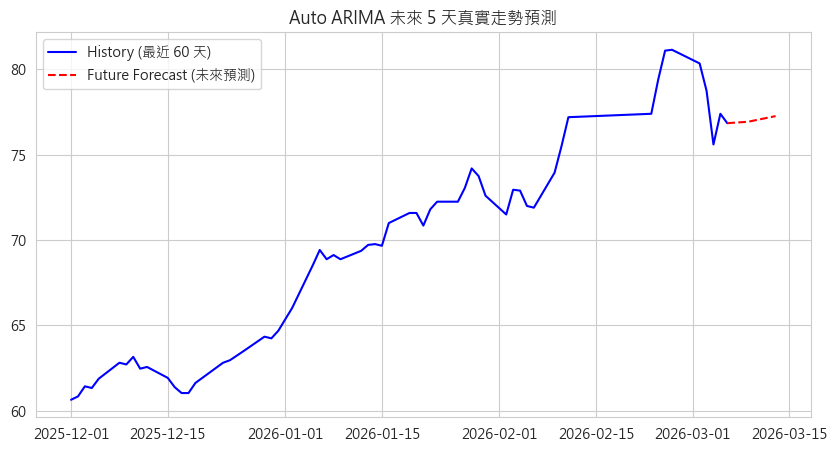

In [9]:
# 備註：Auto ARIMA 會自動尋找最佳的 p, d, q 參數
print("Auto ARIMA 尋找最佳參數中 (使用全部歷史資料進行訓練)...")

# 注意這裡！我們直接傳入 df['Close']，把所有資料都給模型學
arima_model = auto_arima(
    df['Close'], 
    seasonal=False, # 日線收盤價通常無固定季節性
    trace=True,     # 顯示搜尋過程
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

print(arima_model.summary())

# 預測「真正的」未來 5 天
arima_forecast = arima_model.predict(n_periods=forecast_horizon)

# 使用我們剛剛寫好的新函式來畫出未來的圖！
plot_future_forecast(df, arima_forecast, "Auto ARIMA 未來 5 天真實走勢預測")

# 隨機森林 (Random Forest for Multi-step)

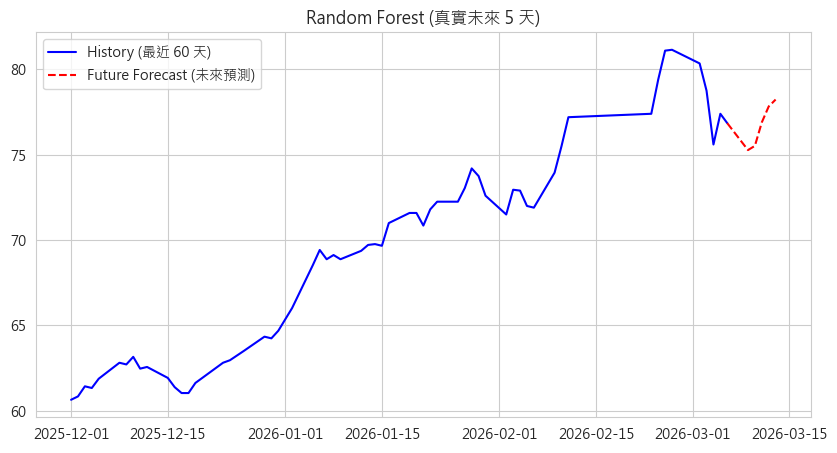

In [10]:
# 備註：樹模型無法自動處理時間序列，我們必須先手動建立 Lag 特徵 (特徵工程)

# 建立特徵矩陣
rf_df = ts_data.copy()
n_lags = 5 # 使用過去 5 天的價格作為特徵

# 建立 X (Lags)
for i in range(1, n_lags + 1):
    rf_df[f'Lag_{i}'] = rf_df['Close'].shift(i)

# 建立 Y (Target T+1 到 T+5) - Option A：一次預測未來 5 天
for i in range(1, forecast_horizon + 1):
    rf_df[f'Target_T+{i}'] = rf_df['Close'].shift(-i + 1) # T+1 就是當天, 因為我們要用昨天的 Lag 預測今天和未來

rf_df = rf_df.dropna()

# 準備 X 和 Y 矩陣
X = rf_df[[f'Lag_{i}' for i in range(1, n_lags + 1)]]
Y = rf_df[[f'Target_T+{i}' for i in range(1, forecast_horizon + 1)]]

# 拆分 Train / Test (這裡的 test 就是我們原本的 last 5 days 時點)
X_train = X.iloc[:-forecast_horizon]
Y_train = Y.iloc[:-forecast_horizon]
# 預測當下 (站在 train 的最後一天，用那天的 Lags 預測未來 5 天)
X_predict = X.iloc[-1:] 

# 建立並訓練模型 (使用 MultiOutputRegressor 來支援一次輸出 5 個預測值)
rf_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
rf_model.fit(X_train, Y_train)

# 進行預測
rf_forecast_values = rf_model.predict(X_predict)[0]
plot_future_forecast(df, rf_forecast_values, "Random Forest (真實未來 5 天)")